# 非线性方程：误差随迭代次数的变化

求解方程

$$\cos x-x=0.$$

使用 SciPy 的 Brent 法计算高精度参考根，再比较二分法、不动点迭代与 Newton 法的逐步误差。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib
configure_matplotlib()
from scipy.optimize import root_scalar

def f(x):
    return np.cos(x) - x

def df(x):
    return -np.sin(x) - 1.0

reference = root_scalar(
    f,
    bracket=(0.0, 1.0),
    method="brentq",
    xtol=1e-14,
).root
print(f"Reference root x* = {reference:.16f}")

Reference root x* = 0.7390851332151612


In [2]:
def bisection_history(left, right, iterations):
    values = []
    for _ in range(iterations):
        midpoint = (left + right) / 2.0
        values.append(midpoint)
        if f(left) * f(midpoint) <= 0:
            right = midpoint
        else:
            left = midpoint
    return np.asarray(values)

def fixed_point_history(x0, iterations):
    values = [x0]
    for _ in range(iterations):
        values.append(np.cos(values[-1]))
    return np.asarray(values)

def newton_history(x0, iterations):
    values = [x0]
    for _ in range(iterations):
        current = values[-1]
        values.append(current - f(current) / df(current))
    return np.asarray(values)

histories = {
    "Bisection": bisection_history(0.0, 1.0, 45),
    "Fixed-point iteration": fixed_point_history(0.5, 45),
    "Newton's method": newton_history(0.5, 8),
}

tiny = np.finfo(float).tiny
errors = {
    name: np.maximum(np.abs(values - reference), tiny)
    for name, values in histories.items()
}

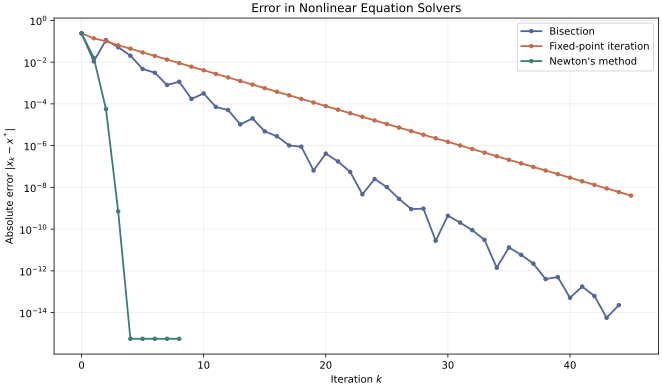

Method                    Iterates    Final absolute error
Bisection        45    2.276e-14
Fixed-point iteration     46    4.021e-09
Newton's method      9    5.551e-16


In [3]:
colors = {
    "Bisection": "#52649a",
    "Fixed-point iteration": "#c26b4a",
    "Newton's method": "#397d78",
}

fig, ax = plt.subplots(figsize=(9.2, 5.4), constrained_layout=True)
for name, values in errors.items():
    ax.semilogy(
        np.arange(len(values)),
        values,
        marker="o",
        markersize=3.5,
        linewidth=1.8,
        color=colors[name],
        label=name,
    )

ax.set(
    title="Error in Nonlinear Equation Solvers",
    xlabel="Iteration $k$",
    ylabel=r"Absolute error $|x_k-x^*|$",
)
ax.grid(True, which="both", alpha=0.22)
ax.legend()
plt.show()

print("Method                    Iterates    Final absolute error")
for name, values in errors.items():
    print(f"{name:<12} {len(values):>6d}    {values[-1]:.3e}")

## 观察

- 二分法误差稳定地按固定比例下降。
- 不动点迭代为线性收敛，速度取决于根附近的压缩系数。
- Newton 法进入根的邻域后误差近似平方下降，很快达到浮点精度。